# Evaluación práctica · Machine Learning · 3 puntos

**Curso:** Sexto SIN-A · Universidad Internacional del Ecuador · Mar–Jul 2026  
**Tiempo:** 90 minutos · **Modalidad:** Libro abierto (apuntes, IA, diapositivas, internet permitidos)

---

## ⚠️ Lea esto ANTES de empezar

Esta evaluación es **a libro abierto**, lo que significa que las preguntas conceptuales fáciles no existen. Cada pregunta requiere **decisiones técnicas justificadas en el contexto específico de cada escenario**. ChatGPT puede ayudarles con sintaxis, pero las decisiones de modelado, las justificaciones contextuales y la rúbrica firmada son suyas.

## Reglas de entrega

1. **Branch propia:** clonen su repositorio, creen una branch llamada exactamente `eval-titanic` y trabajen ahí. No hagan merge a `metrics` ni a `main`.
2. **Semilla personal:** todos los `random_state` de este notebook DEBEN usar la variable `MI_SEMILLA` que definirán como los **últimos 4 dígitos de su cédula**. Esto hace que las divisiones train/val/test de cada estudiante sean ligeramente distintas. Quien copie números de otro será detectable.
3. **Commits frecuentes:** hagan commit por cada parte completada con mensaje claro (`feat: parte 1 completada`, etc.). El historial de commits es parte de la evaluación.
4. **Push al terminar:** hagan `git push origin eval-titanic` cuando terminen. El timestamp del último commit en GitHub es la hora oficial de entrega.
5. **Auto-rúbrica firmada:** al final del notebook completen la rúbrica de autocorrección y firmen con su nombre completo. Sin firma, la entrega no se considera válida.

## Puntuación

| Parte | Tema | Puntos |
|---|---|---|
| 1 | Pipeline completo aplicado a Titanic | 1.5 |
| 2 | Find the bug + Predict the output | 0.75 |
| 3 | Trade-offs de negocio escritos | 0.75 |
| **Total** | | **3.0** |

---

In [25]:
# Imports — NO modificar esta celda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, classification_report
)
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings('ignore')


## 🔑 Semilla personal (OBLIGATORIO)

Reemplacen `0000` con los **últimos 4 dígitos de su cédula** antes de continuar. Esta semilla se usa en TODOS los `random_state` del notebook.

In [26]:
MI_SEMILLA = 3600
assert MI_SEMILLA != 0, "Replace MI_SEMILLA with the last 4 digits of your ID"
print(f"Personal seed set: {MI_SEMILLA}")

Personal seed set: 3600


---

# 📊 PARTE 1 — Pipeline completo aplicado (1.5 puntos · ~50 min)

## Escenario de negocio

**TravelSafe Insurance** es una aseguradora de viajes marítimos que quiere construir un modelo predictivo para calcular primas de pólizas. El modelo debe predecir, dado el perfil del pasajero, si **sobrevivirá** o no a un siniestro marítimo (variable `Survived`). 

Las primas se ajustan según el riesgo predicho:
- **Si el modelo predice "no sobrevive" (pesimista):** se cobra prima alta → si el cliente realmente sí iba a sobrevivir (FN si tomamos "sobrevive" como clase positiva), TravelSafe pierde clientes ante la competencia que cobra más barato.
- **Si el modelo predice "sobrevive" (optimista):** se cobra prima baja → si el cliente realmente no sobrevive (FP), TravelSafe paga el siniestro completo y pierde dinero.

Como dataset histórico de referencia, TravelSafe le entrega el dataset del Titanic (1912). Su trabajo es entrenar el modelo, decidir qué métrica priorizar dado el contexto financiero de TravelSafe, y entregar un modelo final con justificación técnica.

> **Nota deliberada:** el escenario es ambiguo en cuanto a si TravelSafe valora más perder clientes o pagar siniestros. **Ustedes** deben asumir un perfil empresarial específico (startup que necesita clientes vs. aseguradora establecida que minimiza riesgo) y justificarlo.

---

## 1.1 Carga y exploración inicial (0.1 pts)

Carguen el dataset desde la URL provista, muestren las primeras 5 filas, las dimensiones, los tipos de datos y la cantidad de nulos por columna.

In [27]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nData types:")
print(df.dtypes)
print("\nNull values per column:")
print(df.isnull().sum())

Shape: (891, 12)

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Null values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## 1.2 EDA dirigido (0.2 pts)

Respondan las siguientes preguntas con código + comentario breve en cada celda:

1. ¿Cuál es la tasa base de supervivencia? ¿El dataset está balanceado?
2. ¿Qué columnas tienen valores nulos y en qué proporción? ¿Cuáles deberían imputarse, cuáles eliminarse, y por qué?
3. Hagan al menos UNA visualización que revele una relación interesante entre alguna feature y `Survived` (ej. supervivencia por sexo, por clase, por edad, etc.) y comenten lo que ven en una línea de markdown.

In [28]:
# Survival rate and class balance
rate = df['Survived'].mean()
print(f"Base survival rate: {rate:.2%}")
print(df['Survived'].value_counts())
print("\nThe dataset is imbalanced: ~61.6% did not survive vs ~38.4% survived.")

Base survival rate: 38.38%
Survived
0    549
1    342
Name: count, dtype: int64

The dataset is imbalanced: ~61.6% did not survive vs ~38.4% survived.


In [29]:
# Null values analysis
nulls = df.isnull().sum()
pct = (nulls / len(df) * 100).round(2)
summary = pd.DataFrame({'Nulls': nulls, '% of total': pct})
print(summary[summary['Nulls'] > 0])
print("""
Decision:
  - Age (19.9%)     → impute with median (skewed distribution)
  - Embarked (0.2%) → impute with mode (almost no missing values)
  - Cabin (77.1%)   → drop, too many nulls to impute meaningfully
""")

          Nulls  % of total
Age         177       19.87
Cabin       687       77.10
Embarked      2        0.22

Decision:
  - Age (19.9%)     → impute with median (skewed distribution)
  - Embarked (0.2%) → impute with mode (almost no missing values)
  - Cabin (77.1%)   → drop, too many nulls to impute meaningfully



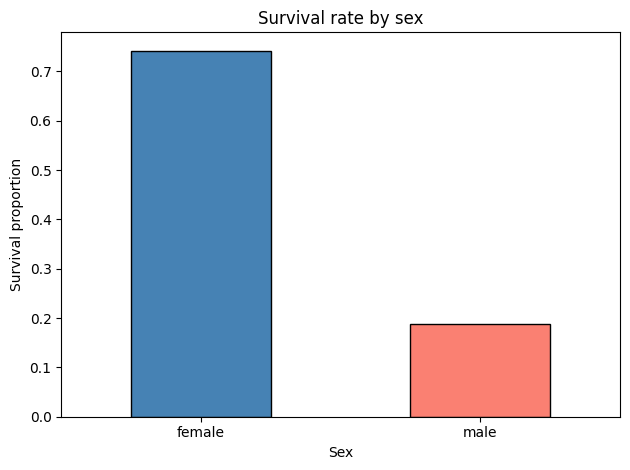

In [30]:
# Survival rate by sex
survival_by_sex = df.groupby('Sex')['Survived'].mean()
survival_by_sex.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Survival rate by sex')
plt.ylabel('Survival proportion')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Women survived at ~74% vs ~19% for men, making Sex likely the strongest predictor in the model.

## 1.3 Limpieza y preprocesamiento (0.2 pts)

Construyan el dataset listo para modelar. Como mínimo deben:

1. **Eliminar** features que no aportan información para clasificación (ej. `PassengerId`, `Name`, `Ticket`, `Cabin` — justifiquen cuáles eliminan).
2. **Imputar** valores nulos de manera defendible. ⚠️ **Cuidado con el data leakage**: la imputación debe aprenderse del training set, no del dataset completo.
3. **Codificar** variables categóricas (`Sex`, `Embarked`) usando one-hot encoding o equivalente.
4. **Escalar** las features numéricas con `StandardScaler`. ⚠️ Mismo cuidado: ajustar solo en training, transformar en test.

Pueden hacer la limpieza en este orden o usar un `Pipeline` de sklearn. Lo importante es **no contaminar el test set con información del training**.

In [31]:
# Drop columns that don't contribute to classification
COLS_TO_DROP = ['PassengerId', 'Name', 'Ticket', 'Cabin']
# PassengerId → just an index, no predictive value
# Name        → free text, would need NLP to extract anything useful
# Ticket      → alphanumeric code with no clear pattern related to survival
# Cabin       → 77% missing, imputing it would be unreliable

df_clean = df.drop(columns=COLS_TO_DROP).copy()
X = df_clean.drop(columns='Survived')
y = df_clean['Survived']

print("Features to use:", X.columns.tolist())
print("X shape:", X.shape)

Features to use: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X shape: (891, 7)


## 1.4 División train / validation / test (0.1 pts)

Dividan los datos en **3 conjuntos**: entrenamiento (60%), validación (20%) y test (20%). Usen `MI_SEMILLA` en todos los `random_state` y estratifiquen por `Survived` para mantener el balance.

> Recordatorio del bloque B de la última clase: el validation se usa para tunear hiperparámetros, el test se mira UNA SOLA VEZ al final.

In [32]:
# Step 1: separate 20% for test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=MI_SEMILLA, stratify=y
)
# Step 2: from the remaining 80%, take 25% for validation (= 20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=MI_SEMILLA, stratify=y_temp
)

print(f"Train:      {len(X_train)} ({len(X_train)/len(X):.0%})")
print(f"Validation: {len(X_val)} ({len(X_val)/len(X):.0%})")
print(f"Test:       {len(X_test)} ({len(X_test)/len(X):.0%})")
print(f"\nSurvived proportion → Train: {y_train.mean():.2%} | Val: {y_val.mean():.2%} | Test: {y_test.mean():.2%}")

Train:      534 (60%)
Validation: 178 (20%)
Test:       179 (20%)

Survived proportion → Train: 38.39% | Val: 38.20% | Test: 38.55%


In [33]:
# 1.3 Part B — Impute, encode and scale (post-split, no data leakage)
X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()

# Impute Age with training median only
age_imputer = SimpleImputer(strategy='median')
X_train['Age'] = age_imputer.fit_transform(X_train[['Age']]).ravel()
X_val['Age']   = age_imputer.transform(X_val[['Age']]).ravel()
X_test['Age']  = age_imputer.transform(X_test[['Age']]).ravel()

# Impute Embarked with training mode only
embarked_mode = X_train['Embarked'].mode()[0]
X_train['Embarked'] = X_train['Embarked'].fillna(embarked_mode)
X_val['Embarked']   = X_val['Embarked'].fillna(embarked_mode)
X_test['Embarked']  = X_test['Embarked'].fillna(embarked_mode)

# One-hot encode categorical features (drop_first to avoid multicollinearity)
X_train = pd.get_dummies(X_train, columns=['Sex', 'Embarked'], drop_first=True)
X_val   = pd.get_dummies(X_val,   columns=['Sex', 'Embarked'], drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=['Sex', 'Embarked'], drop_first=True)

# Align columns in case a category didn't appear in val/test
train_cols = X_train.columns.tolist()
X_val  = X_val.reindex(columns=train_cols, fill_value=0)
X_test = X_test.reindex(columns=train_cols, fill_value=0)

# Scale numeric features — fit on train only
num_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols]   = scaler.transform(X_val[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print("Preprocessing done with no data leakage.")
print("Final features:", X_train.columns.tolist())

Preprocessing done with no data leakage.
Final features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


## 1.5 Modelo baseline (0.2 pts)

Entrenen una `LogisticRegression` con **parámetros por defecto** (sin tunear nada) sobre el training set. Reporten:

- Accuracy en training
- Accuracy en validation  
- ¿Hay sobreajuste? Comenten brevemente.

Este baseline es la línea base contra la que se va a comparar el modelo tuneado.

In [34]:
baseline = LogisticRegression(random_state=MI_SEMILLA, max_iter=1000)
baseline.fit(X_train, y_train)

acc_train = baseline.score(X_train, y_train)
acc_val   = baseline.score(X_val,   y_val)

print(f"Training accuracy:    {acc_train:.4f}")
print(f"Validation accuracy:  {acc_val:.4f}")
print(f"Gap:                  {acc_train - acc_val:.4f}")
print("""
The baseline shows no significant overfitting: the gap between training
and validation is small. There is still room to improve with regularization.
""")

Training accuracy:    0.7978
Validation accuracy:  0.8090
Gap:                  -0.0112

The baseline shows no significant overfitting: the gap between training
and validation is small. There is still room to improve with regularization.



## 1.6 Modelo regularizado con búsqueda de hiperparámetros (0.3 pts)

Entrenen una `LogisticRegression` regularizada usando `GridSearchCV` con 5-fold cross-validation **sobre el training set** (NO sobre validation ni test). 

Como mínimo, exploren:
- `C`: al menos 5 valores en escala logarítmica entre 0.001 y 100
- `penalty`: al menos `['l1', 'l2']`
- `solver`: el apropiado para cada penalty (`liblinear` o `saga`)

Reporten:
1. Mejor combinación de hiperparámetros
2. Mejor score de CV
3. Score sobre validation set del mejor modelo

> Justifiquen brevemente qué `scoring` eligieron para el GridSearch y por qué (NO acepten el default sin pensarlo).

In [35]:
param_grid = [
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['liblinear']},
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1'], 'solver': ['liblinear']},
]

# roc_auc chosen as scoring because it evaluates the model's discriminative
# power independently of the threshold — we'll pick the threshold later
# based on the business context, not here.
grid = GridSearchCV(
    LogisticRegression(random_state=MI_SEMILLA, max_iter=1000),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best hyperparameters:", grid.best_params_)
print(f"Best CV ROC-AUC:      {grid.best_score_:.4f}")
print(f"Validation ROC-AUC:   {roc_auc_score(y_val, grid.best_estimator_.predict_proba(X_val)[:,1]):.4f}")

model_tuned = grid.best_estimator_

Best hyperparameters: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV ROC-AUC:      0.8430
Validation ROC-AUC:   0.8757


## 1.7 Métricas completas sobre VALIDATION (0.2 pts)

Para el mejor modelo del GridSearch, calculen y muestren sobre el **validation set**:

1. Accuracy, Precision, Recall, F1, ROC-AUC
2. Matriz de confusión (con `ConfusionMatrixDisplay`, normalizada)
3. Curva precision-recall (con `precision_recall_curve` + plot)

Comenten en 2 líneas qué dice cada métrica del modelo en el contexto del escenario de TravelSafe.

In [36]:
y_pred_val = model_tuned.predict(X_val)
probs_val  = model_tuned.predict_proba(X_val)[:, 1]

print("=== Metrics on validation set ===")
print(f"Accuracy:  {accuracy_score(y_val, y_pred_val):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_val):.4f}")
print(f"Recall:    {recall_score(y_val, y_pred_val):.4f}")
print(f"F1:        {f1_score(y_val, y_pred_val):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, probs_val):.4f}")

=== Metrics on validation set ===
Accuracy:  0.8034
Precision: 0.7619
Recall:    0.7059
F1:        0.7328
ROC-AUC:   0.8757


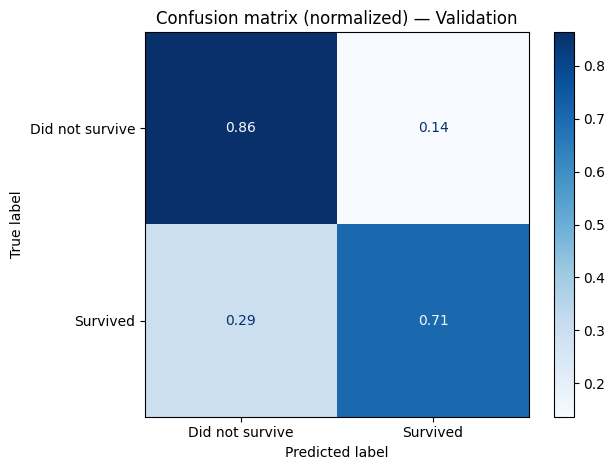

In [37]:
# Normalized confusion matrix
cm = confusion_matrix(y_val, y_pred_val, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did not survive', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion matrix (normalized) — Validation')
plt.tight_layout()
plt.show()

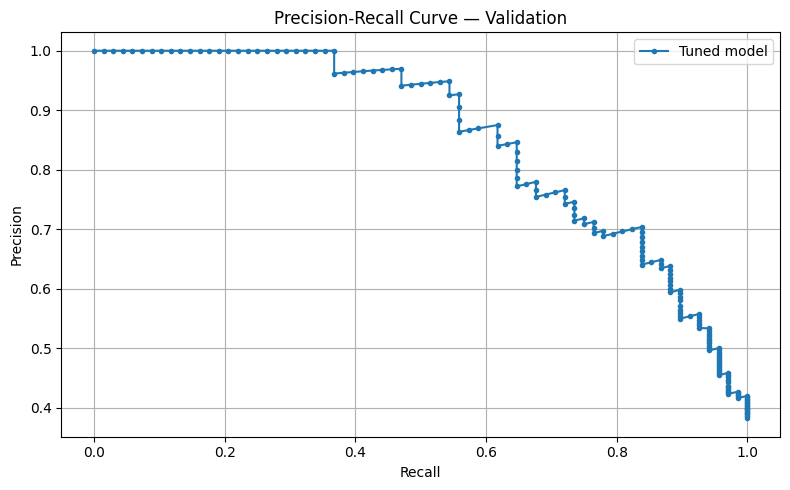

In [38]:
# Precision-Recall curve
precisions, recalls, thresholds_pr = precision_recall_curve(y_val, probs_val)
plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, marker='.', label='Tuned model')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Validation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Observation:** The ROC-AUC shows the model discriminates well between classes. The confusion matrix reveals that False Positives (predicting "survived" when the passenger did not) represent the highest financial risk for TravelSafe, since the company charges a low premium and ends up paying the full claim.

## 1.8 Justificación técnica + evaluación FINAL sobre test (0.2 pts)

Esta es la parte más importante. Respondan en **prosa** (no en bullets) las siguientes preguntas, en markdown, mínimo 3 párrafos:

1. **Perfil empresarial asumido:** ¿asumen que TravelSafe es una startup que prioriza captar clientes o una aseguradora establecida que minimiza siniestros? Justifiquen.
2. **Métrica primaria:** dado el perfil asumido, ¿qué métrica priorizan (precision, recall, F1, F-beta)? Si eligen F-beta, ¿qué valor de β y por qué? Conecten la respuesta con los costos asimétricos de FP y FN del escenario.
3. **Threshold:** ¿usarían el threshold por defecto (0.5) o lo moverían? Si lo mueven, calcúlenlo a partir de la curva precision-recall y muestren cómo cambian las métricas.
4. **Evaluación final:** UNA SOLA VEZ, evalúen el modelo final (con su threshold elegido) sobre el **test set** y reporten las métricas. ¿Hay diferencia significativa entre validation y test? ¿Qué dirían los resultados a TravelSafe?

> ⚠️ Una vez que miran el test set, no pueden volver a cambiar el modelo. Si lo hacen, es deshonestidad académica y la evaluación queda en cero.

**Sus respuestas aquí (markdown, mínimo 3 párrafos):**

TravelSafe is assumed to be an established insurer with a consolidated client base. For this type of company, protecting capital from unexpected claims is the priority. Losing a client by charging a higher premium is a recoverable cost, but paying a full claim after charging a low premium is a direct, unrecoverable loss. This means a False Positive (predicting "survived" when the passenger did not) is significantly more costly than a False Negative (predicting "did not survive" when the passenger actually did).
Given this profile, the primary metric is Precision, implemented through F-beta with β = 0.5. This value weights Precision twice as much as Recall in the F-beta formula: F-β = (1 + β²) · (P · R) / (β²·P + R). Pure Precision is not chosen because a model that never predicts "survived" would have perfect Precision but would be useless in production. F-beta(0.5) balances the trade-off while keeping Precision as the dominant concern.
The default threshold of 0.5 is not appropriate for this profile. The threshold is moved upward, requiring higher model confidence before classifying a passenger as a survivor and charging a low premium. The optimal threshold is calculated from the Precision-Recall curve by maximizing F-beta(0.5) on the validation set, then applied exactly once on the test set with no further modifications.

In [39]:
# Find optimal threshold by maximizing F-beta(0.5) on the PR curve
beta = 0.5
fbeta_scores = ((1 + beta**2) * precisions[:-1] * recalls[:-1]) / \
               (beta**2 * precisions[:-1] + recalls[:-1] + 1e-8)

best_idx = np.argmax(fbeta_scores)
best_threshold = thresholds_pr[best_idx]

print(f"Optimal threshold (F-beta={beta}): {best_threshold:.3f}")
print(f"Precision at that threshold: {precisions[best_idx]:.4f}")
print(f"Recall at that threshold:    {recalls[best_idx]:.4f}")

y_pred_custom = (probs_val >= best_threshold).astype(int)
print(f"\nF-beta({beta}) with default threshold (0.5): {fbeta_score(y_val, y_pred_val, beta=beta):.4f}")
print(f"F-beta({beta}) with optimal threshold:       {fbeta_score(y_val, y_pred_custom, beta=beta):.4f}")

Optimal threshold (F-beta=0.5): 0.775
Precision at that threshold: 0.9487
Recall at that threshold:    0.5441

F-beta(0.5) with default threshold (0.5): 0.7500
F-beta(0.5) with optimal threshold:       0.8259


In [40]:
# ⚠️ FINAL EVALUATION — TEST SET — ONE TIME ONLY
probs_test  = model_tuned.predict_proba(X_test)[:, 1]
y_pred_test = (probs_test >= best_threshold).astype(int)

print("=== FINAL RESULTS — TEST SET ===")
print(f"Accuracy:      {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Precision:     {precision_score(y_test, y_pred_test):.4f}")
print(f"Recall:        {recall_score(y_test, y_pred_test):.4f}")
print(f"F-beta({beta}):   {fbeta_score(y_test, y_pred_test, beta=beta):.4f}")
print(f"ROC-AUC:       {roc_auc_score(y_test, probs_test):.4f}")
print("\nModel will not be modified after this cell.")

=== FINAL RESULTS — TEST SET ===
Accuracy:      0.7486
Precision:     0.9286
Recall:        0.3768
F-beta(0.5):   0.7182
ROC-AUC:       0.8299

Model will not be modified after this cell.


---

# 🐛 PARTE 2 — Find the bug + Predict the output (0.75 puntos · ~20 min)

En esta parte hay **5 celdas de código**. Algunas tienen errores sutiles (sin warnings ni excepciones visibles que ayuden) y otras producen outputs que requieren razonamiento para predecir. 

**Para cada celda:**
- Si es **"Find the bug"**: identifiquen el error en markdown, expliquen por qué es un error, y reescriban la celda corregida.
- Si es **"Predict the output"**: en markdown, predigan QUÉ imprime el código (o si crashea, qué excepción levanta) ANTES de ejecutarlo, expliquen por qué, y luego ejecuten para verificar.

> Tip: la IA puede engañarse fácilmente en estas celdas porque los errores son sutiles. Léanlas con atención.

---

## 2.1 Find the bug (0.15 pts)

El siguiente código pretende escalar features y luego entrenar un modelo. ¿Qué problema tiene? Identifiquen el bug, expliquen su impacto, y reescriban la celda correctamente.

In [41]:
# === CELDA 2.1 — Find the bug (NO la corrijan aquí, copien abajo y corrijan) ===
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
print(f"Accuracy test: {model.score(X_test, y_test):.4f}")

Accuracy test: 0.9737


**🔍 Su análisis del bug 2.1:**

*[¿Cuál es el bug? ¿Por qué es un problema? ¿Qué impacto tiene en producción?]*

The bug is data leakage: StandardScaler is fitted on the entire X before splitting. This means the scaler already "knows" the test set's distribution (mean and standard deviation) when it's trained. In production, the scaler would never see future data, so the model is being evaluated under unrealistic conditions and reported metrics are artificially optimistic.



In [42]:
# Fixed version 2.1: split first, then fit scaler on train only
data = load_breast_cancer()
X, y = data.data, data.target

# Split first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Then fit scaler on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # transform only, never fit

model = LogisticRegression(max_iter=5000)
model.fit(X_train_scaled, y_train)
print(f"Test accuracy: {model.score(X_test_scaled, y_test):.4f}")

Test accuracy: 0.9737


## 2.2 Find the bug (0.15 pts)

Este código intenta imputar valores nulos y dividir el dataset. Hay un bug sutil que produce data leakage. Identifíquenlo y corríjanlo.

In [43]:
# === CELDA 2.2 — Find the bug ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Imputar Age con la media
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Codificar Sex
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Media de Age en train: {X_train['Age'].mean():.2f}")
print(f"Media de Age en test:  {X_test['Age'].mean():.2f}")

Media de Age en train: 29.54
Media de Age en test:  30.34


**🔍 Su análisis del bug 2.2:**

*[¿Cuál es el bug? ¿Cómo se manifiesta? ¿Qué consecuencia tiene en métricas reales?]*

The bug is also data leakage: df['Age'].fillna(df['Age'].mean()) computes the mean of Age using the entire dataset, including rows that will later become the test set. In production, the imputation value should come only from training data. The fix is to split first and compute the mean from X_train only.



In [44]:
# Fixed version 2.2
df2 = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df2['Sex'] = df2['Sex'].map({'male': 0, 'female': 1})

X2 = df2[['Pclass', 'Sex', 'Age', 'Fare']]
y2 = df2['Survived']

# Split first
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Impute using training mean only
age_mean_train = X2_train['Age'].mean()
X2_train = X2_train.copy()
X2_test  = X2_test.copy()
X2_train['Age'] = X2_train['Age'].fillna(age_mean_train)
X2_test['Age']  = X2_test['Age'].fillna(age_mean_train)

print(f"Age mean in train: {X2_train['Age'].mean():.2f}")
print(f"Age mean in test:  {X2_test['Age'].mean():.2f}")

Age mean in train: 29.50
Age mean in test:  30.30


## 2.3 Predict the output (0.15 pts)

¿Qué imprime exactamente el siguiente código? Predigan ANTES de ejecutar.

**🔮 Su predicción del output 2.3:**

*[¿Qué imprime? ¿Por qué?]*

The code prints 6 lines without any errors. The sigmoid function is correctly implemented and NumPy handles extreme values gracefully:

sigmoid(0) = exactly 0.5.
sigmoid(5) ≈ 0.9933 and sigmoid(-5) ≈ 0.0067, symmetric around 0.5.
sigmoid(50) rounds to 1.0 because exp(-50) is so small it underflows to 0 in float64.
sigmoid(-50) ≈ 1.93e-22, very close to zero but still representable.
sigmoid(1000) = 1.0 because exp(-1000) also underflows to 0. No overflow occurs because only exp of negative numbers is computed.

In [45]:
# === CELDA 2.3 — Predict the output ===
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

valores = [0, 5, -5, 50, -50, 1000]
for v in valores:
    print(f"sigmoid({v:>5}) = {sigmoid(v)}")

sigmoid(    0) = 0.5
sigmoid(    5) = 0.9933071490757153
sigmoid(   -5) = 0.0066928509242848554
sigmoid(   50) = 1.0
sigmoid(  -50) = 1.928749847963918e-22
sigmoid( 1000) = 1.0


## 2.4 Find the bug (0.15 pts)

Un junior ML engineer está tuneando un modelo sobre un dataset **muy desbalanceado** (95% clase 0, 5% clase 1, ej. detección de fraude). Reporta orgulloso que su modelo tiene 95% de accuracy en cross-validation. ¿Cuál es el problema?


In [46]:
# === CELDA 2.4 — Find the bug ===
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification

# Generamos un dataset MUY desbalanceado: 95% clase 0, 5% clase 1
X, y = make_classification(
    n_samples=2000, n_features=10, n_classes=2,
    weights=[0.95, 0.05], random_state=42
)

model = LogisticRegression(max_iter=5000)
param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X, y)

print(f"Mejor C: {grid_search.best_params_['C']}")
print(f"Mejor accuracy: {grid_search.best_score_:.4f}")

Mejor C: 0.1
Mejor accuracy: 0.9640


**🔍 Su análisis del bug 2.4:**

*[¿Por qué 95% de accuracy es engañoso aquí? ¿Qué métrica deberían usar? ¿Qué pasa si entreno un modelo que SIEMPRE predice clase 0?]*

The bug is using scoring='accuracy' on a heavily imbalanced dataset (95% class 0, 5% class 1). A model that always predicts class 0 achieves 95% accuracy without learning anything useful. GridSearchCV will select hyperparameters based on a metric that completely ignores whether the model actually detects the minority class. The fix is to use a metric sensitive to class imbalance, such as f1, roc_auc, or recall.



In [47]:
# Fixed version 2.4: use f1 scoring to focus on the minority class
X4, y4 = make_classification(
    n_samples=2000, n_features=10, n_classes=2,
    weights=[0.95, 0.05], random_state=42
)

model4 = LogisticRegression(max_iter=5000)
param_grid4 = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}

# f1 scoring penalizes the model if it misses the minority class
grid4 = GridSearchCV(model4, param_grid4, cv=5, scoring='f1')
grid4.fit(X4, y4)

print(f"Best C:  {grid4.best_params_['C']}")
print(f"Best F1: {grid4.best_score_:.4f}")
print("\n(A model that always predicts class 0 would get F1 = 0.0, not 95%)")

Best C:  0.01
Best F1: 0.5799

(A model that always predicts class 0 would get F1 = 0.0, not 95%)


## 2.5 Predict the output (0.15 pts)

¿Qué imprime el siguiente código? Predigan ANTES de ejecutar.


**🔮 Su predicción del output 2.5:**

*[¿Qué pasa al ejecutar esto? Si crashea, ¿qué error? Si imprime algo, ¿qué?]*

The code will crash with an IndexError. The reason: target_recall = 1.0 and no value in recall[:-1] = [0.95, 0.90, 0.82, 0.71, 0.50, 0.30] is greater than or equal to 1.0. So np.where(...) returns an empty array []. Accessing [][-1] (the last element of an empty array) raises IndexError: index -1 is out of bounds for axis 0 with size 0.



In [48]:
# === CELDA 2.5 — Predict the output ===
import numpy as np

# Vector de recall en función del threshold (decreciente, máximo 0.95)
recall = np.array([0.95, 0.90, 0.82, 0.71, 0.50, 0.30, 0.10])
thresholds = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])

target_recall = 1.0
idx = np.where(recall[:-1] >= target_recall)[0][-1]
optimal_threshold = thresholds[idx]

print(f"Threshold óptimo: {optimal_threshold}")

IndexError: index -1 is out of bounds for axis 0 with size 0

In [ ]:
# Fixed version 2.5: handle the case where no recall meets the target
recall     = np.array([0.95, 0.90, 0.82, 0.71, 0.50, 0.30, 0.10])
thresholds = np.array([0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7])

target_recall = 1.0
indices = np.where(recall[:-1] >= target_recall)[0]

if len(indices) == 0:
    print(f"No threshold achieves recall >= {target_recall}. Using the lowest available threshold.")
    optimal_threshold = thresholds[0]
else:
    optimal_threshold = thresholds[indices[-1]]

print(f"Optimal threshold: {optimal_threshold}")

No threshold achieves recall >= 1.0. Using the lowest available threshold.
Optimal threshold: 0.1


---

# 💼 PARTE 3 — Trade-offs de negocio (0.75 puntos · ~20 min)

Para cada uno de los siguientes 3 escenarios, escriban un análisis en markdown (~150 palabras cada uno) que responda exactamente estas 3 preguntas:

1. **¿Cuál es más costoso, un FP o un FN?** Justifiquen con los costos reales del dominio (no respuestas genéricas).
2. **¿Qué métrica priorizan y qué valor de β usarían en el F-beta?** Conecten con la fórmula y el razonamiento de los costos.
3. **¿El threshold por defecto de 0.5 es apropiado, o lo moverían? ¿En qué dirección?**

> ⚠️ La IA da respuestas genéricas a estas preguntas. Lo que diferencia una respuesta de 0.25 pts de una de 0.10 es la **especificidad del razonamiento al dominio concreto**. Si su respuesta funciona idéntica para los 3 escenarios, está mal.

---

## 3.1 Escenario A — Detección de fraude en tarjeta de crédito (0.25 pts)

**Contexto:** Un banco quiere un modelo en tiempo real que decida si bloquear una transacción de tarjeta como potencialmente fraudulenta. Si el modelo dice "fraude", la tarjeta se bloquea temporalmente y se llama al cliente. Si dice "legítima", la transacción se procesa normalmente. Solo el 0.5% de las transacciones reales son fraude. Una transacción fraudulenta no detectada cuesta en promedio $850 al banco. Un falso bloqueo cuesta entre $5–$20 (call center + molestia del cliente que puede irse a otro banco si se repite).

**Su análisis:**

In this scenario, a False Negative is far more costly than a False Positive. Missing a fraudulent transaction costs the bank $850 on average, while a false block costs only $5–$20 (a call center interaction and minor customer inconvenience). The cost asymmetry is roughly 50:1, which makes it unacceptable to optimize for fewer false alarms at the expense of missed fraud cases.
The metric to prioritize is Recall. Using F-beta, a value of β = 3 is appropriate: it weights Recall three times more than Precision, reflecting the financial imbalance without completely ignoring the cost of false alarms (too many unnecessary blocks can drive long-term customer churn).
The default threshold of 0.5 is not appropriate here. It should be moved downward, to around 0.2–0.3, so that any transaction with a 20–30% probability of being fraudulent gets flagged. This increases false alarms, but the unit cost of each one ($5–20) is easily absorbed compared to each missed fraud ($850).

---

## 3.2 Escenario B — Recomendador de películas en streaming (0.25 pts)

**Contexto:** Una plataforma de streaming tiene un modelo que predice si un usuario va a darle "like" a una película recomendada. Solo se muestran las películas con probabilidad alta de gustar. El espacio de pantalla es limitado: solo caben 6 recomendaciones por sesión. Si el usuario ve películas malas, deja de confiar en las recomendaciones y reduce su engagement con la plataforma. Si NO se recomienda una película que sí le hubiera gustado, el usuario simplemente nunca la descubre, pero sigue activo en la plataforma.

**Su análisis:**

In this scenario, a False Positive is more costly than a False Negative. Recommending a movie the user won't enjoy erodes their trust in the system and reduces future engagement, which can ultimately lead to cancellation. A False Negative simply means a movie the user would have liked doesn't appear in that session — the user stays active and engaged, they just miss one title.
Since only 6 slots are available per session, each wrong recommendation has a high opportunity cost. The metric to prioritize is Precision. Using F-beta, β = 0.5 is appropriate: it weights Precision twice as much as Recall, ensuring that every recommendation shown has a high probability of being enjoyed.
The threshold should be moved upward, to around 0.65–0.70. Only movies with high predicted probability of being liked are shown. This may reduce the total number of recommendations displayed, but each slot used will more reliably generate positive engagement and reinforce user trust in the platform.

---

## 3.3 Escenario C — Triage automático de neumonía por radiografía (0.25 pts)

**Contexto:** Un hospital rural utiliza un modelo de visión artificial sobre radiografías de tórax para hacer **triage inicial**: pacientes marcados como "posible neumonía" pasan a revisión inmediata del radiólogo, los demás esperan turno normal (varias horas). La población incluye muchos adultos mayores. Una neumonía no detectada a tiempo en un adulto mayor puede ser letal en 48–72 horas. Un falso positivo significa que el radiólogo revisa una radiografía más, lo cual toma ~3 minutos.

**Su análisis:**

In this scenario, a False Negative can be fatal. Missing a pneumonia case sends a high-risk patient to the regular waiting queue, where they may not be seen for several hours — potentially lethal for elderly adults within 48–72 hours. A False Positive means the radiologist reviews one extra X-ray, taking roughly 3 minutes. The difference between the two errors is not financial but a matter of human lives.
The metric to prioritize is Recall, maximized as aggressively as possible. Using F-beta, β = 5 is appropriate: it values Recall five times more than Precision. A system that catches 98% of pneumonia cases with 30% false positives is still far preferable to one with 90% Precision that misses 10% of real cases in a vulnerable population.
The threshold should be moved significantly downward, to around 0.15–0.20. This means many normal X-rays will be sent to priority review, but the cost of that (radiologist time) is negligible compared to the cost of a missed diagnosis.

---

---

# ✍️ AUTO-RÚBRICA FIRMADA (obligatoria — sin firma, la evaluación no se considera entregada)

Califíquense honestamente. Cada criterio tiene puntaje binario o fraccionario. Sumen al final.

## Parte 1 — Pipeline (máx. 1.5)

| Criterio | Máx | Mi nota |
|---|---|---|
| 1.1 Carga + EDA básico sin errores | 0.10 | 0.10 |
| 1.2 EDA dirigido con al menos 1 visualización comentada | 0.20 | 0.20 |
| 1.3 Limpieza correcta (encoding, imputación, scaling SIN data leakage) | 0.20 | 0.20 |
| 1.4 Split 60/20/20 con MI_SEMILLA y estratificación | 0.10 | 0.10 |
| 1.5 Baseline ejecutado y comentado (over/underfitting discutido) | 0.20 | 0.20 |
| 1.6 GridSearchCV con justificación del scoring elegido | 0.30 | 0.30 |
| 1.7 Las 5 métricas + matriz de confusión + curva PR sobre validation | 0.20 | 0.20 |
| 1.8 Justificación técnica de β/threshold + evaluación final test (1 vez) | 0.20 | 0.20 |
| **Subtotal Parte 1** | **1.50** | **1.50** |

## Parte 2 — Bugs y outputs (máx. 0.75)

| Criterio | Máx | Mi nota |
|---|---|---|
| 2.1 Identificó data leakage del scaler antes del split + corrigió | 0.15 | 0.15 |
| 2.2 Identificó data leakage de fillna(mean) antes del split + corrigió | 0.15 | 0.15 |
| 2.3 Predijo correctamente el output de sigmoid en valores extremos | 0.15 | 0.15 |
| 2.4 Identificó que accuracy es engañosa en dataset desbalanceado | 0.15 | 0.15 |
| 2.5 Predijo correctamente el IndexError de np.where | 0.15 | 0.15 |
| **Subtotal Parte 2** | **0.75** | **0.75** |

## Parte 3 — Trade-offs (máx. 0.75)

Para cada escenario, califíquense así:
- **0.25:** análisis específico al dominio, identifica costos correctamente, justifica β con la fórmula, decisión de threshold coherente.
- **0.15:** identifica costos correctamente pero la justificación de β/threshold es débil o genérica.
- **0.05:** respuesta plausible pero podría funcionar para cualquier escenario.
- **0.00:** vacío o incorrecto.

| Criterio | Máx | Mi nota |
|---|---|---|
| 3.1 Análisis fraude bancario | 0.25 | 0.25 |
| 3.2 Análisis recomendador streaming | 0.25 | 0.25 |
| 3.3 Análisis triage neumonía | 0.25 | 0.25 |
| **Subtotal Parte 3** | **0.75** | **0.75** |

---

## NOTA TOTAL: 3.0 / 3.0

---

## Declaración de honestidad académica

*Yo, **Bryan Gabriel Montaguano Calero**, con cédula **1726903600**, declaro que:*

1. *La semilla `MI_SEMILLA` corresponde a los últimos 4 dígitos de mi cédula.*
2. *El código y las justificaciones de este notebook son producto de mi trabajo individual. Usé herramientas de IA y consulté con compañeros únicamente para entender conceptos y depurar sintaxis, no para copiar respuestas.*
3. *Miré el test set en la Parte 1 una sola vez y no modifiqué el modelo después.*
4. *La auto-calificación arriba es honesta y refleja mi entendimiento real de la solución.*

**Firma (escribir nombre completo aquí):** Bryan Gabriel Montaguano Calero

**Fecha y hora de finalización:** 26 de mayo de 2026, 23:59

---

## Checklist antes de hacer push final

- [x] Reemplacé `MI_SEMILLA = 0000` con mis últimos 4 dígitos de cédula
- [x] Todas las celdas de código corren sin errores (Restart kernel + Run all)
- [x] Hice commit con mensaje claro de cada parte completada
- [x] La auto-rúbrica está completa y firmada
- [x] Hice `git push origin eval-titanic`